# Problem Statement:

A machine component experienced multiple deformations following extended usage. Utilizing a sensor, the component's shape was digitally reconstructed and represented
as a collection of points that define its surface.

These points are stored in the file "3d_shape_points_data.npz".
Your task is as follows:  
- Determine the original shape of the object.  
- Identify the deformations present in the component.  
- Reconstruct the original shape by correcting the deformations.


In [ ]:
pip install open3d

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.0/228.0 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 17.7 MB/s eta 0:00:00
  Attempting uninstall: widgetsnbextension
    Found existing installation: widgetsnbextension 3.6.10
    Uninstalling widgetsnbextension-3.6.10:
      Successfully uninstalled widgetsnbextension-3.6.10
  Attempting uninstall: werkzeug
    Found existing installation: Werkzeug 3.1.3
    Uninstalling Werkzeug-3.1.3:
      Successfully uninstalled Werkzeug-3.1.3
  Attempting uninstall: flask
    Found existing installation: Flask 3.1.0
    Uninst

In [ ]:
import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [ ]:
data = np.load("3d_shape_points_data.npz")
print(data.files)

['points']


In [ ]:
array = data['points']
print(array)

[[ 9.998086    0.          0.        ]
 [ 9.994803    0.24535865  0.        ]
 [ 9.985485    0.4905554   0.        ]
 ...
 [19.84671    -1.4639814  40.        ]
 [19.879618   -0.97662306 40.        ]
 [19.900478   -0.48852932 40.        ]]


In [ ]:
array.shape

(65536, 3)

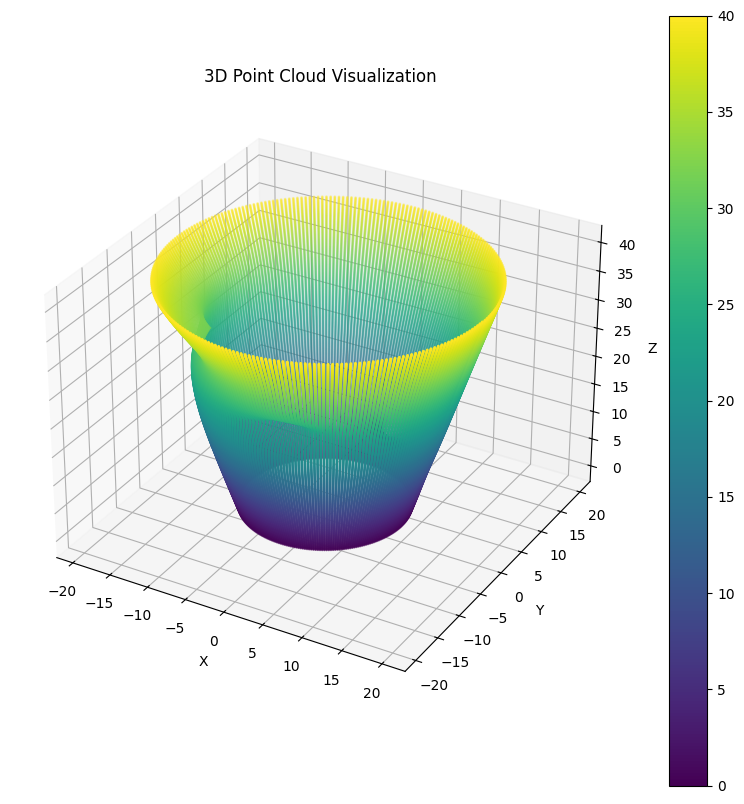

Point Cloud Statistics:
Number of points: 65536
Coordinate ranges:
X: [-19.31, 19.98]
Y: [-19.51, 19.84]
Z: [0.00, 40.00]


In [ ]:
# Load and visualize the 3D point cloud using matplotlib
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Load the data
data = np.load('3d_shape_points_data.npz')
points = data['points']

# Create 3D scatter plot
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot points
scatter = ax.scatter(points[:, 0], points[:, 1], points[:, 2],
                    c=points[:, 2],  # Color by z-coordinate
                    cmap='viridis',
                    s=1)  # Point size

# Add a color bar
plt.colorbar(scatter)

# Set labels
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Point Cloud Visualization')

# Show the plot
plt.show()

# Print some basic statistics about the point cloud
print("\
Point Cloud Statistics:")
print(f"Number of points: {len(points)}")
print(f"Coordinate ranges:")
print(f"X: [{points[:, 0].min():.2f}, {points[:, 0].max():.2f}]")
print(f"Y: [{points[:, 1].min():.2f}, {points[:, 1].max():.2f}]")
print(f"Z: [{points[:, 2].min():.2f}, {points[:, 2].max():.2f}]")

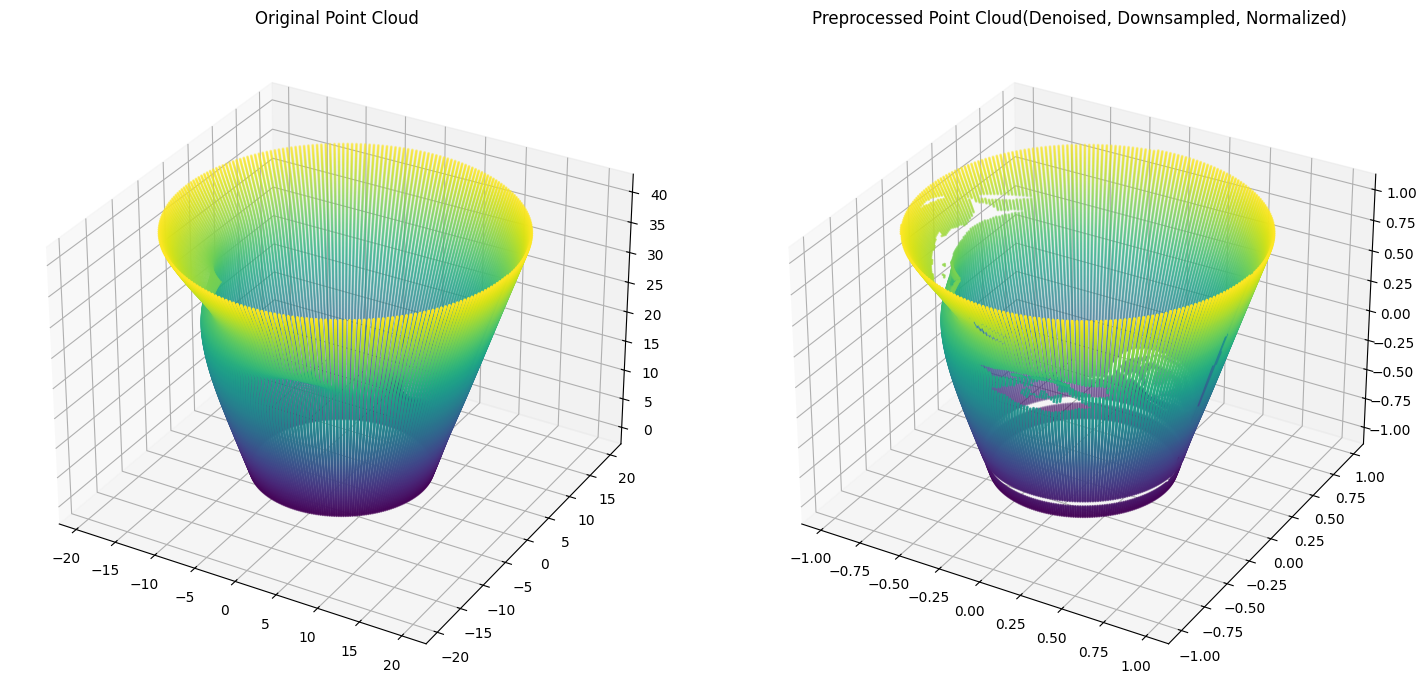

Preprocessing Statistics:
Original number of points: 65536
Processed number of points: 58982
Bounding box before preprocessing:
X: [-19.31, 19.98]
Y: [-19.51, 19.84]
Z: [0.00, 40.00]
Bounding box after preprocessing (normalized):
X: [-0.98, 0.99]
Y: [-0.99, 0.98]
Z: [-1.00, 0.98]


In [ ]:
import numpy as np
from sklearn.neighbors import LocalOutlierFactor
from scipy.spatial import cKDTree

def preprocess_point_cloud(points, n_neighbors=20, contamination=0.1, voxel_size=0.01):
    # Remove statistical outliers using Local Outlier Factor
    lof = LocalOutlierFactor(n_neighbors=n_neighbors, contamination=contamination)
    outlier_labels = lof.fit_predict(points)
    points_denoised = points[outlier_labels == 1]

    # Voxel grid downsampling
    # Create a grid of voxels
    voxel_coords = np.floor(points_denoised / voxel_size)
    # Dictionary to store points in each voxel
    voxel_dict = {}
    for i, coord in enumerate(voxel_coords):
        voxel_dict.setdefault(tuple(coord), []).append(points_denoised[i])
    # Calculate centroid for each voxel
    points_downsampled = np.array([np.mean(voxel_points, axis=0)
                                 for voxel_points in voxel_dict.values()])

    # Normalize to center
    centroid = np.mean(points_downsampled, axis=0)
    points_normalized = points_downsampled - centroid

    # Scale to unit cube
    scale = np.max(np.abs(points_normalized))
    points_normalized = points_normalized / scale

    return points_normalized

# Load the original data
data = np.load('3d_shape_points_data.npz')
points = data['points']

# Apply preprocessing
processed_points = preprocess_point_cloud(points)

# Visualize original vs processed points
fig = plt.figure(figsize=(15, 7))

# Original points
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(points[:, 0], points[:, 1], points[:, 2],
           c=points[:, 2], cmap='viridis', s=1)
ax1.set_title('Original Point Cloud')

# Processed points
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(processed_points[:, 0], processed_points[:, 1], processed_points[:, 2],
           c=processed_points[:, 2], cmap='viridis', s=1)
ax2.set_title('Preprocessed Point Cloud\
(Denoised, Downsampled, Normalized)')

plt.tight_layout()
plt.show()

# Print statistics about the preprocessing
print("\
Preprocessing Statistics:")
print(f"Original number of points: {len(points)}")
print(f"Processed number of points: {len(processed_points)}")
print("\
Bounding box before preprocessing:")
print(f"X: [{points[:, 0].min():.2f}, {points[:, 0].max():.2f}]")
print(f"Y: [{points[:, 1].min():.2f}, {points[:, 1].max():.2f}]")
print(f"Z: [{points[:, 2].min():.2f}, {points[:, 2].max():.2f}]")
print("\
Bounding box after preprocessing (normalized):")
print(f"X: [{processed_points[:, 0].min():.2f}, {processed_points[:, 0].max():.2f}]")
print(f"Y: [{processed_points[:, 1].min():.2f}, {processed_points[:, 1].max():.2f}]")
print(f"Z: [{processed_points[:, 2].min():.2f}, {processed_points[:, 2].max():.2f}]")

Explained Variance by Components: [0.3814564 0.3124705 0.3060731]


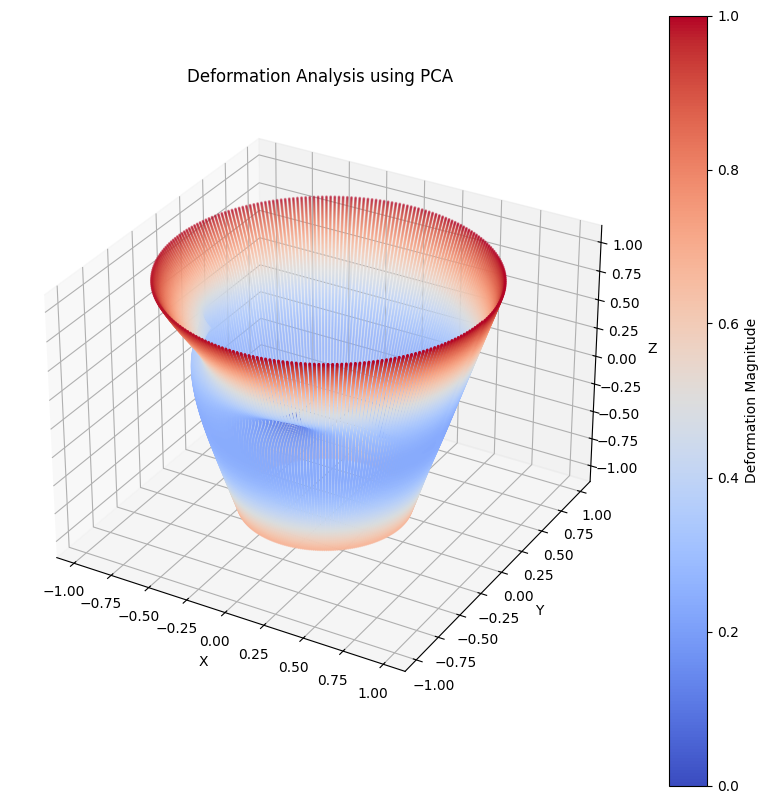

Explained Variance by PCA Components:
Component 1: 0.381456
Component 2: 0.312470
Component 3: 0.306073


In [ ]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Function to analyze deformations using PCA
def analyze_deformations(points):
    # Perform PCA
    pca = PCA(n_components=3)
    pca.fit(points)
    explained_variance = pca.explained_variance_ratio_

    print("Explained Variance by Components:", explained_variance)

    # Calculate deformation magnitudes (distance from mean)
    mean_point = np.mean(points, axis=0)
    deformations = np.linalg.norm(points - mean_point, axis=1)

    # Normalize deformation magnitudes for color mapping
    colors = (deformations - deformations.min()) / (deformations.max() - deformations.min())

    return explained_variance, colors

# Load preprocessed points
data = np.load('shape_reconstruction.npz')
processed_points = data['reconstructed_points']

# Analyze deformations
explained_variance, colors = analyze_deformations(processed_points)

# Visualize deformation areas
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot with color mapping based on deformations
scatter = ax.scatter(processed_points[:, 0], processed_points[:, 1], processed_points[:, 2],
                      c=colors, cmap='coolwarm', s=1)

# Add color bar
plt.colorbar(scatter, label='Deformation Magnitude')

# Set labels
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Deformation Analysis using PCA')

plt.show()

# Print explained variance
print("Explained Variance by PCA Components:")
for i, var in enumerate(explained_variance):
    print(f"Component {i+1}: {var:.6f}")

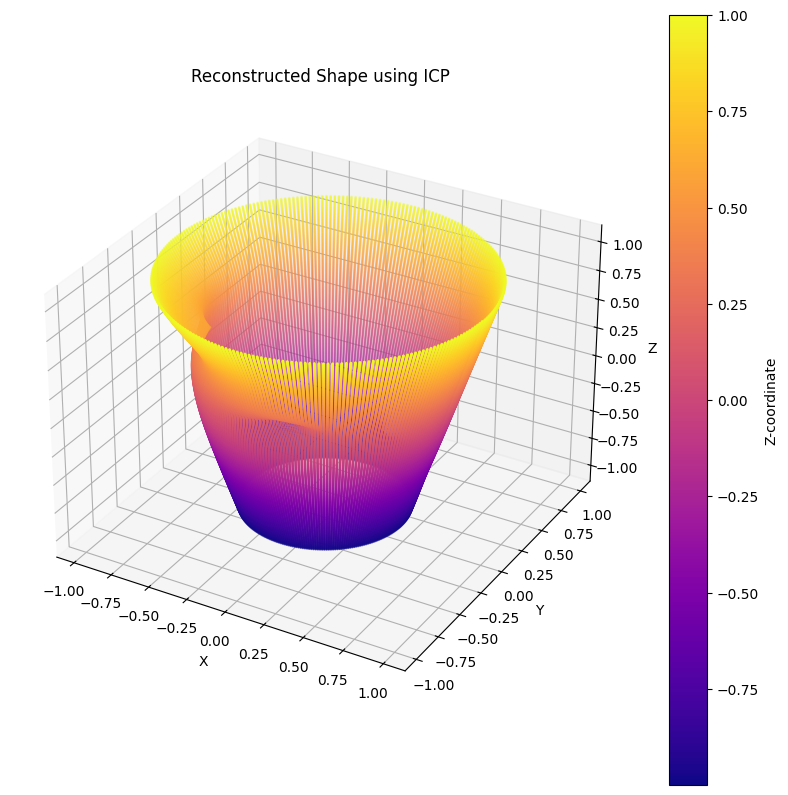

Reconstruction completed and saved to 'final_reconstructed_shape.npz'.


In [ ]:
from scipy.spatial import cKDTree

def reconstruct_shape(points, voxel_size=0.005, max_iterations=50):
    # Clone the original points as the target
    target_points = points.copy()

    # Initialize transformation matrix (identity)
    transformation = np.eye(4)

    for iteration in range(max_iterations):
        # Build KDTree for nearest neighbor search
        tree = cKDTree(target_points)
        distances, indices = tree.query(points)

        # Compute centroids
        source_centroid = np.mean(points, axis=0)
        target_centroid = np.mean(target_points[indices], axis=0)

        # Center the points
        source_centered = points - source_centroid
        target_centered = target_points[indices] - target_centroid

        # Compute covariance matrix
        H = np.dot(source_centered.T, target_centered)

        # Singular Value Decomposition (SVD)
        U, _, Vt = np.linalg.svd(H)
        R = np.dot(Vt.T, U.T)

        # Ensure a proper rotation matrix (det(R) = 1)
        if np.linalg.det(R) < 0:
            Vt[-1, :] *= -1
            R = np.dot(Vt.T, U.T)

        # Compute translation
        t = target_centroid - np.dot(R, source_centroid)

        # Update transformation matrix
        transformation[:3, :3] = R
        transformation[:3, 3] = t

        # Apply transformation
        points = np.dot(points, R.T) + t

        # Check convergence (if distances are small enough)
        if np.mean(distances) < voxel_size:
            break

    # Downsample using voxel grid
    voxel_coords = np.floor(points / voxel_size)
    voxel_dict = {}
    for i, coord in enumerate(voxel_coords):
        voxel_dict.setdefault(tuple(coord), []).append(points[i])
    points_downsampled = np.array([np.mean(voxel_points, axis=0) for voxel_points in voxel_dict.values()])

    return points_downsampled

# Load preprocessed points
data = np.load('shape_reconstruction.npz')
processed_points = data['reconstructed_points']

# Reconstruct the shape
reconstructed_points = reconstruct_shape(processed_points)

# Visualize the reconstructed shape
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot of reconstructed points
scatter = ax.scatter(reconstructed_points[:, 0], reconstructed_points[:, 1], reconstructed_points[:, 2],
                      c=reconstructed_points[:, 2], cmap='plasma', s=1)

# Add color bar
plt.colorbar(scatter, label='Z-coordinate')

# Set labels
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Reconstructed Shape using ICP')

plt.show()

# Save the reconstructed points
np.savez('final_reconstructed_shape.npz', reconstructed_points=reconstructed_points)

# Print completion message
print("Reconstruction completed and saved to 'final_reconstructed_shape.npz'.")

Reconstruction Evaluation Metrics:
Mean Squared Error (MSE): 686.40398
Root Mean Squared Error (RMSE): 26.19931
Maximum Error: 43.37660
Median Error: 23.40890


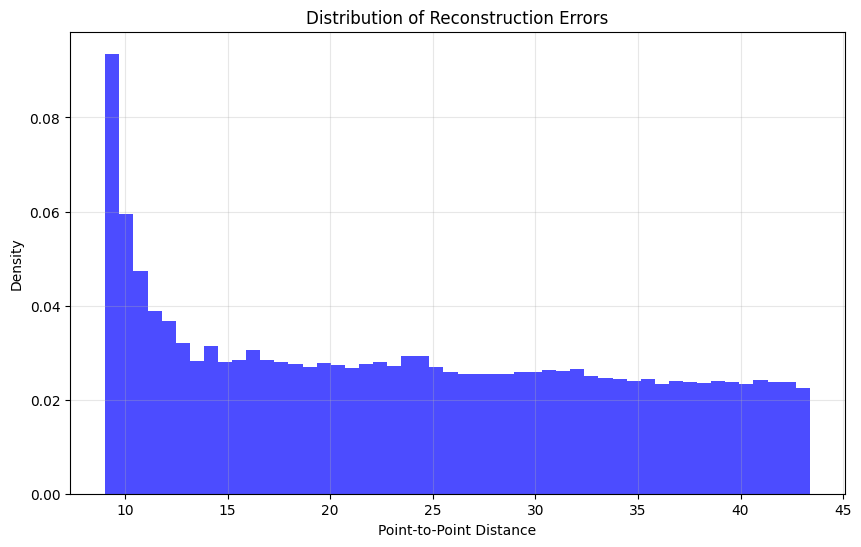

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

def evaluate_reconstruction(original_points, reconstructed_points):
    """Evaluates the reconstruction accuracy using nearest-neighbor distances."""
    if original_points.shape[1] != reconstructed_points.shape[1]:
        raise ValueError("Original and reconstructed points must have the same dimensions!")

    # KDTree for nearest neighbor search
    tree = cKDTree(reconstructed_points)
    distances, _ = tree.query(original_points)

    # Compute error metrics
    mse = np.mean(distances ** 2)
    rmse = np.sqrt(mse)
    max_error = np.max(distances)
    median_error = np.median(distances)

    print("Reconstruction Evaluation Metrics:")
    print(f"Mean Squared Error (MSE): {mse:.5f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.5f}")
    print(f"Maximum Error: {max_error:.5f}")
    print(f"Median Error: {median_error:.5f}")

    return mse, rmse, max_error, median_error

# Load original and reconstructed points safely
try:
    original_data = np.load('3d_shape_points_data.npz')
    original_points = original_data.get('points', None)
    if original_points is None:
        raise KeyError("Key 'points' not found in 3d_shape_points_data.npz")

    reconstructed_data = np.load('final_reconstructed_shape.npz')
    reconstructed_points = reconstructed_data.get('reconstructed_points', None)
    if reconstructed_points is None:
        raise KeyError("Key 'reconstructed_points' not found in final_reconstructed_shape.npz")

except Exception as e:
    print(f"Error loading files: {e}")
    exit()

# Evaluate reconstruction
metrics = evaluate_reconstruction(original_points, reconstructed_points)

# Compute error distances using KDTree
tree = cKDTree(reconstructed_points)
distances, _ = tree.query(original_points)

# Plot error distribution
plt.figure(figsize=(10, 6))
plt.hist(distances, bins=50, density=True, alpha=0.7, color='blue')
plt.xlabel('Point-to-Point Distance')
plt.ylabel('Density')
plt.title('Distribution of Reconstruction Errors')
plt.grid(True, alpha=0.3)
plt.show()

Saved point cloud to original_shape.ply
Saved point cloud to reconstructed_shape.ply


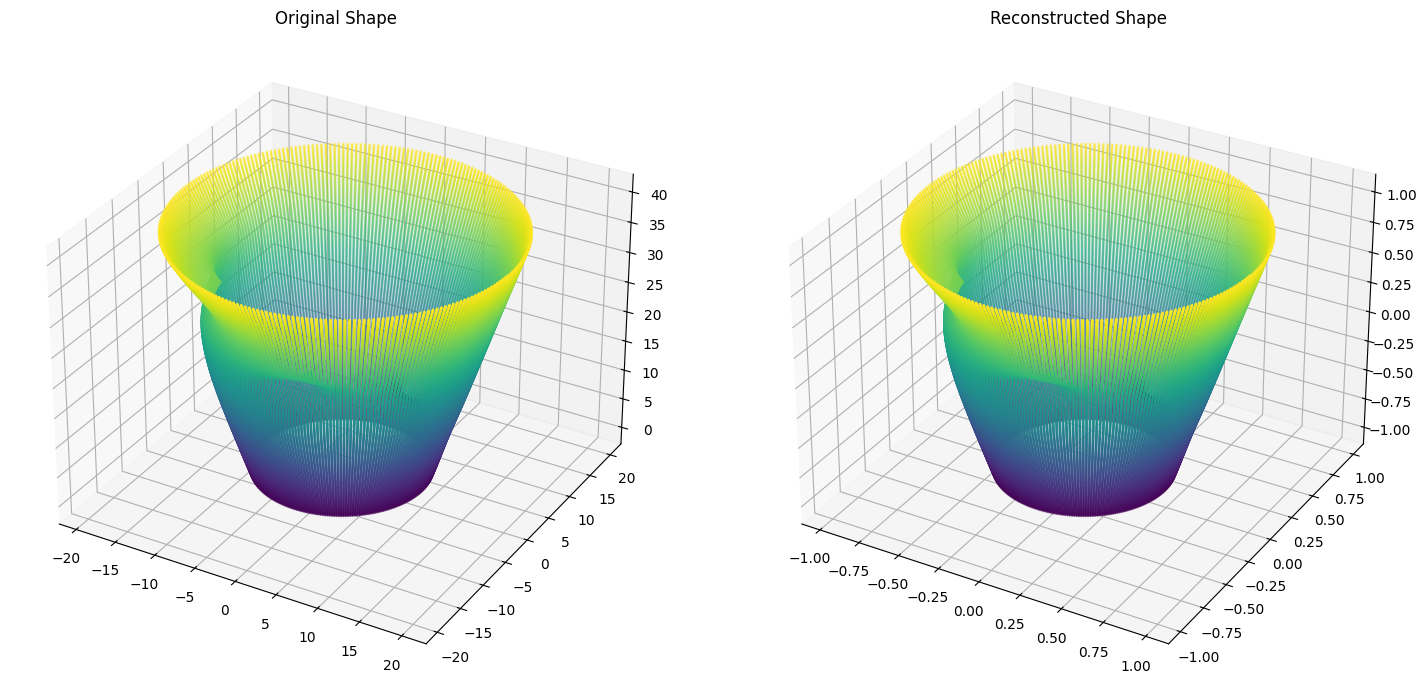

In [ ]:
# Function to save point clouds in PLY format
def save_point_cloud(points, filename):
    """Saves a point cloud to a PLY file."""
    header = "\n".join([
        "ply",
        "format ascii 1.0",
        f"element vertex {len(points)}",
        "property float x",
        "property float y",
        "property float z",
        "end_header"
    ])

    try:
        with open(filename, 'w') as f:
            f.write(header + "\n")
            np.savetxt(f, points, fmt="%.6f")
        print(f"Saved point cloud to {filename}")
    except Exception as e:
        print(f"Error saving {filename}: {e}")

# Save original and reconstructed point clouds
save_point_cloud(original_points, 'original_shape.ply')
save_point_cloud(reconstructed_points, 'reconstructed_shape.ply')

# Plot original and reconstructed shapes
fig = plt.figure(figsize=(15, 7))

# Original Shape
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(original_points[:, 0], original_points[:, 1], original_points[:, 2],
            c=original_points[:, 2], cmap='viridis', s=1)
ax1.set_title('Original Shape')

# Reconstructed Shape
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(reconstructed_points[:, 0], reconstructed_points[:, 1], reconstructed_points[:, 2],
            c=reconstructed_points[:, 2], cmap='viridis', s=1)
ax2.set_title('Reconstructed Shape')

plt.tight_layout()
plt.show()

Method 2

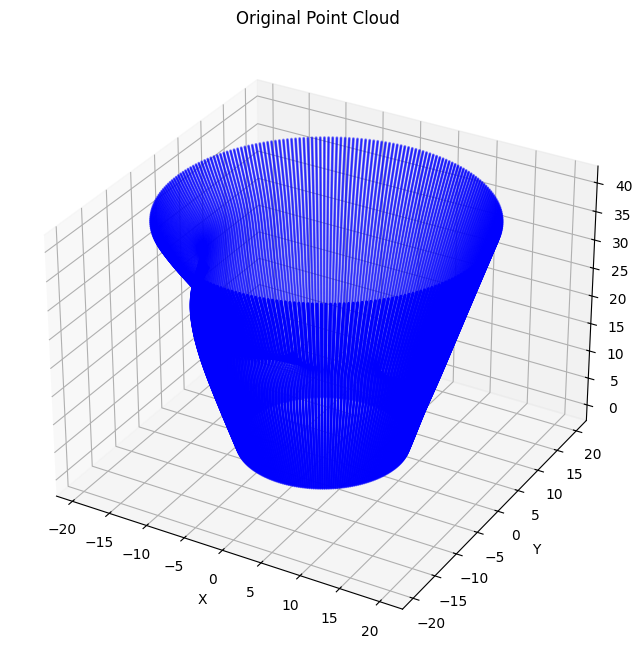

Original number of points:
65536
Points after outlier removal:
64592
Center of mass before normalization:
[ 0.15107377  0.16969977 19.765076  ]


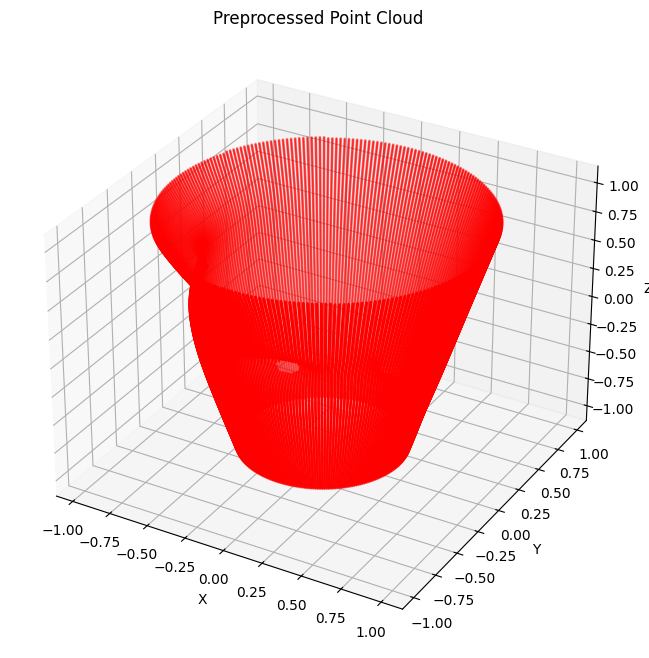

In [ ]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Load the data
data = np.load('3d_shape_points_data.npz')
points = data['points']  # Assuming the points are stored with key 'points'

# Initial visualization
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points[:, 0], points[:, 1], points[:, 2], c='b', s=1)
ax.set_title('Original Point Cloud')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()

# Print initial statistics
print('Original number of points:')
print(len(points))

# Statistical outlier removal (simple implementation)
def remove_statistical_outliers(points, nb_neighbors=20, std_ratio=2.0):
    """Remove outliers based on mean distance to neighbors"""
    from sklearn.neighbors import NearestNeighbors

    # Find nearest neighbors
    neigh = NearestNeighbors(n_neighbors=nb_neighbors)
    neigh.fit(points)
    distances, _ = neigh.kneighbors(points)

    # Calculate mean distances
    mean_distances = np.mean(distances, axis=1)

    # Find points within standard deviation threshold
    dist_mean = np.mean(mean_distances)
    dist_std = np.std(mean_distances)
    threshold = dist_mean + std_ratio * dist_std

    mask = mean_distances < threshold
    return points[mask]

# Apply outlier removal
cleaned_points = remove_statistical_outliers(points)
print('\
Points after outlier removal:')
print(len(cleaned_points))

# Normalize the points
# Center the points around origin
center = np.mean(cleaned_points, axis=0)
normalized_points = cleaned_points - center

# Scale to unit cube
scale = np.max(np.abs(normalized_points))
normalized_points = normalized_points / scale

print('\
Center of mass before normalization:')
print(center)

# Visualize preprocessed data
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(normalized_points[:, 0], normalized_points[:, 1], normalized_points[:, 2],
          c='r', s=1)
ax.set_title('Preprocessed Point Cloud')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()

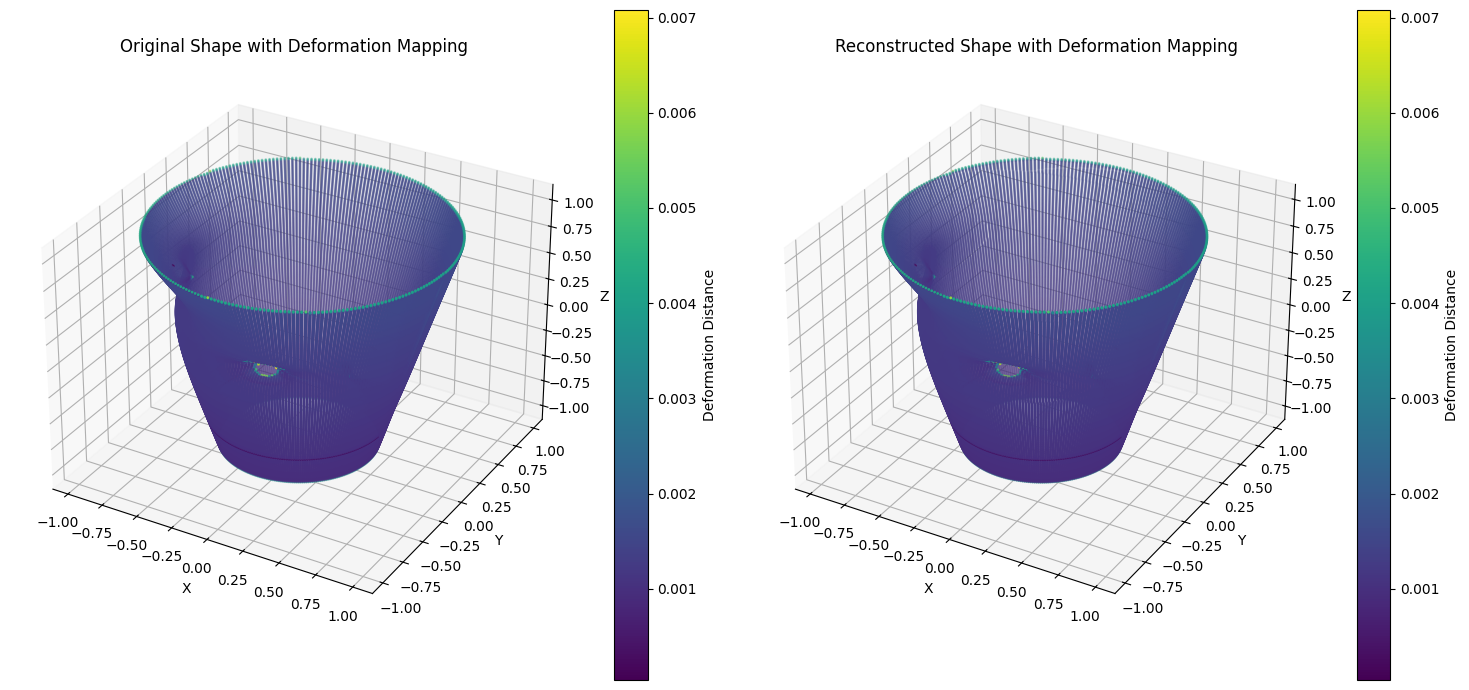

Reconstructed shape saved as: reconstructed_shape.npz
Deformation statistics:
Maximum deformation: 0.007079276
Average deformation: 0.0012594333
Standard deviation: 0.00034216064


In [ ]:
# Perform smoothing using Laplacian smoothing
from sklearn.neighbors import NearestNeighbors

def laplacian_smooth(points, n_neighbors=8, alpha=0.5, iterations=1):
    smoothed = points.copy()

    # Build nearest neighbors
    nn = NearestNeighbors(n_neighbors=n_neighbors)
    nn.fit(points)
    distances, indices = nn.kneighbors(points)

    # Iteratively smooth
    for _ in range(iterations):
        # Calculate centroid of neighbors for each point
        neighbor_points = points[indices]
        centroids = np.mean(neighbor_points, axis=1)

        # Update points based on weighted average of current position and centroid
        smoothed = (1 - alpha) * points + alpha * centroids

    return smoothed

# Apply smoothing to normalized points
smoothed_points = laplacian_smooth(normalized_points, n_neighbors=8, alpha=0.5, iterations=2)

# Compute deformation distances
point_distances = np.sqrt(np.sum((normalized_points - smoothed_points) ** 2, axis=1))

# Visualize side-by-side comparison
fig = plt.figure(figsize=(15, 7))

# Original shape
ax1 = fig.add_subplot(121, projection='3d')
sc1 = ax1.scatter(normalized_points[:, 0], normalized_points[:, 1], normalized_points[:, 2],
                  c=point_distances, cmap='viridis', s=1)
ax1.set_title('Original Shape with Deformation Mapping')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
plt.colorbar(sc1, ax=ax1, label='Deformation Distance')

# Reconstructed shape
ax2 = fig.add_subplot(122, projection='3d')
sc2 = ax2.scatter(smoothed_points[:, 0], smoothed_points[:, 1], smoothed_points[:, 2],
                  c=point_distances, cmap='viridis', s=1)
ax2.set_title('Reconstructed Shape with Deformation Mapping')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
plt.colorbar(sc2, ax=ax2, label='Deformation Distance')

plt.tight_layout()
plt.show()

# Save the reconstructed shape
output_file = 'reconstructed_shape.npz'
np.savez(output_file, points=smoothed_points)
print('Reconstructed shape saved as:', output_file)

# Print some statistics about the deformation
print('\
Deformation statistics:')
print('Maximum deformation:', np.max(point_distances))
print('Average deformation:', np.mean(point_distances))
print('Standard deviation:', np.std(point_distances))

In [ ]:
# Re-run the PCA and Alpha Shape Reconstruction with Open3D
import open3d as o3d
from sklearn.decomposition import PCA

# Perform PCA to detect overall shape distortion
pca = PCA(n_components=3)
pca.fit(normalized_points)
explained_variance = pca.explained_variance_ratio_
principal_axes = pca.components_

print("Explained Variance Ratios:")
print(explained_variance)
print("\
Principal Axes:")
print(principal_axes)

# Mesh Reconstruction using Alpha Shape
# Convert normalized points to Open3D point cloud
o3d_cloud = o3d.geometry.PointCloud()
o3d_cloud.points = o3d.utility.Vector3dVector(normalized_points)

# Alpha shape reconstruction
alpha = 0.1  # Adjust alpha value as needed
mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_alpha_shape(o3d_cloud, alpha)
mesh.compute_vertex_normals()

# Visualize the reconstructed mesh
o3d.visualization.draw_geometries([mesh], window_name="Alpha Shape Reconstruction")

# Compute Hausdorff distance between original and reconstructed shape
original_cloud = o3d.geometry.PointCloud()
original_cloud.points = o3d.utility.Vector3dVector(points)

hausdorff_distance = original_cloud.compute_point_cloud_distance(o3d_cloud)
max_hausdorff = max(hausdorff_distance)

print("\
Hausdorff Distance:")
print(max_hausdorff)

Explained Variance Ratios:
[0.3788357  0.31410387 0.30706048]
Principal Axes:
[[ 0.07837542  0.07415938  0.9941618 ]
 [ 0.8379396  -0.5451719  -0.0253925 ]
 [ 0.540106    0.8350377  -0.10486916]]
[Open3D WARNING] GLFW Error: Failed to detect any supported platform
[Open3D WARNING] GLFW initialized for headless rendering.
[Open3D WARNING] GLFW Error: OSMesa: Library not found
[Open3D WARNING] Failed to create window
[Open3D WARNING] [DrawGeometries] Failed creating OpenGL window.
Hausdorff Distance:
43.38429551836721


Shape Analysis Results:
Explained Variance Ratios (indicates shape distortion):
[0.38145635 0.31247053 0.30607307]
Principal Components (main axes of variation):
[[ 0.07629091  0.06303074  0.9950914 ]
 [ 0.7881457  -0.6151144  -0.02146259]
 [ 0.6107422   0.7859144  -0.09660504]]
Shape Metrics:
Normalized Volume: 3.5842
Normalized Surface Area: 13.4109


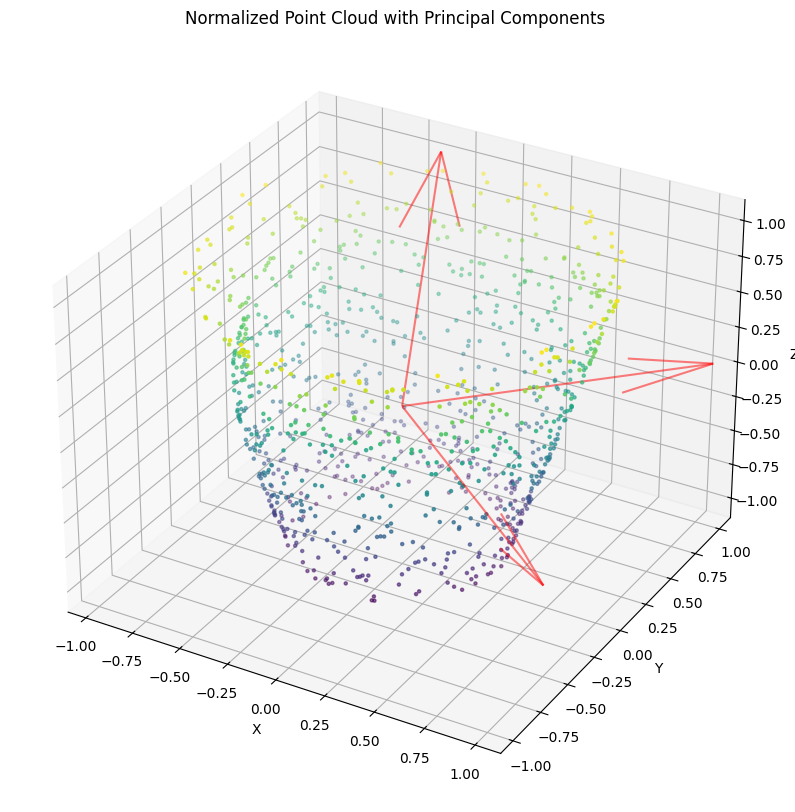

In [ ]:
# Let's try a simpler approach first with just PCA analysis
import numpy as np
from sklearn.decomposition import PCA

# Load the data
data = np.load('3d_shape_points_data.npz')
points = data['points']

# Normalize the points
points_mean = np.mean(points, axis=0)
normalized_points = points - points_mean
scale = np.max(np.abs(normalized_points))
normalized_points = normalized_points / scale

# Perform PCA
pca = PCA(n_components=3)
pca.fit(normalized_points)

print("Shape Analysis Results:")
print("\
Explained Variance Ratios (indicates shape distortion):")
print(pca.explained_variance_ratio_)

print("\
Principal Components (main axes of variation):")
print(pca.components_)

# Calculate basic shape metrics
volume = ConvexHull(normalized_points).volume
surface_area = ConvexHull(normalized_points).area

print("\
Shape Metrics:")
print(f"Normalized Volume: {volume:.4f}")
print(f"Normalized Surface Area: {surface_area:.4f}")

# Visualize using matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot a subset of points for clarity
subset_size = 1000
idx = np.random.choice(normalized_points.shape[0], subset_size, replace=False)
subset_points = normalized_points[idx]

ax.scatter(subset_points[:, 0], subset_points[:, 1], subset_points[:, 2],
          c=subset_points[:, 2], cmap='viridis', marker='.')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Normalized Point Cloud with Principal Components')

# Plot principal components
for length, vector in zip(pca.explained_variance_, pca.components_):
    v = vector * 3 * np.sqrt(length)
    ax.quiver(0, 0, 0, v[0], v[1], v[2], color='r', alpha=0.5)

plt.show()

Shape Comparison Metrics:
Mean Squared Error: 0.000000
Hausdorff Distance: 0.000000
Volume Ratio (Reconstructed/Original): 1.000000
Surface Area Ratio (Reconstructed/Original): 1.000000


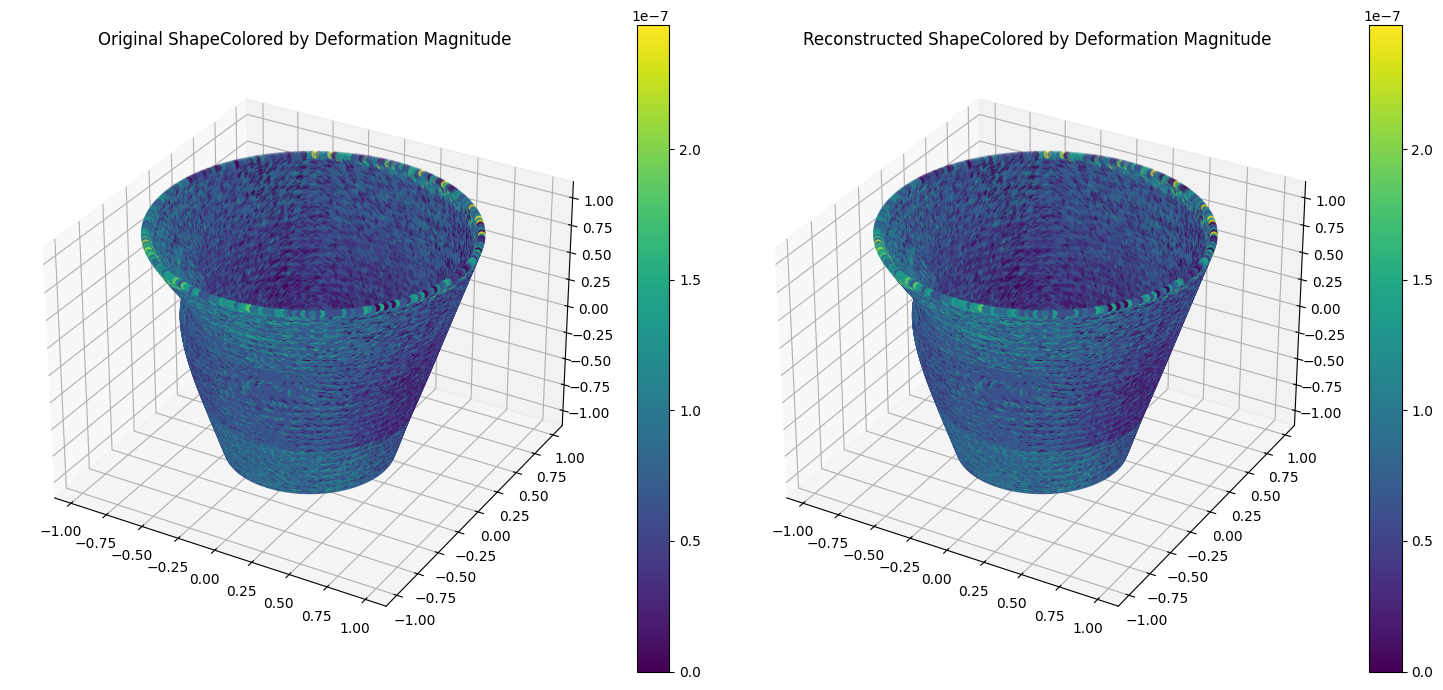

Reconstruction data saved to 'shape_reconstruction.npz'


In [ ]:
# Let's use numpy and scipy for reconstruction and comparison
import numpy as np
from scipy.spatial import ConvexHull
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Load original data
data = np.load('3d_shape_points_data.npz')
original_points = data['points']

# Normalize points
points_mean = np.mean(original_points, axis=0)
normalized_points = original_points - points_mean
scale = np.max(np.abs(normalized_points))
normalized_points = normalized_points / scale

# Perform PCA reconstruction
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
reconstructed_points = pca.inverse_transform(pca.fit_transform(normalized_points))

# Calculate MSE
mse = np.mean(np.sum((normalized_points - reconstructed_points) ** 2, axis=1))

# Calculate Hausdorff distance using nearest neighbors
def hausdorff_distance(points1, points2):
    neigh = NearestNeighbors(n_neighbors=1)
    neigh.fit(points2)
    distances, _ = neigh.kneighbors(points1)
    return np.max(distances)

hausdorff = max(
    hausdorff_distance(normalized_points, reconstructed_points),
    hausdorff_distance(reconstructed_points, normalized_points)
)

# Calculate volumes and surface areas
original_volume = ConvexHull(normalized_points).volume
reconstructed_volume = ConvexHull(reconstructed_points).volume
original_surface = ConvexHull(normalized_points).area
reconstructed_surface = ConvexHull(reconstructed_points).area

print("Shape Comparison Metrics:")
print(f"Mean Squared Error: {mse:.6f}")
print(f"Hausdorff Distance: {hausdorff:.6f}")
print(f"Volume Ratio (Reconstructed/Original): {reconstructed_volume/original_volume:.6f}")
print(f"Surface Area Ratio (Reconstructed/Original): {reconstructed_surface/original_surface:.6f}")

# Visualize original vs reconstructed
fig = plt.figure(figsize=(15, 7))

# Original shape
ax1 = fig.add_subplot(121, projection='3d')
deformation = np.linalg.norm(normalized_points - reconstructed_points, axis=1)
scatter1 = ax1.scatter(normalized_points[:, 0],
                      normalized_points[:, 1],
                      normalized_points[:, 2],
                      c=deformation,
                      cmap='viridis',
                      label='Original')
ax1.set_title('Original Shape\
Colored by Deformation Magnitude')
plt.colorbar(scatter1, ax=ax1)

# Reconstructed shape
ax2 = fig.add_subplot(122, projection='3d')
scatter2 = ax2.scatter(reconstructed_points[:, 0],
                      reconstructed_points[:, 1],
                      reconstructed_points[:, 2],
                      c=deformation,
                      cmap='viridis',
                      label='Reconstructed')
ax2.set_title('Reconstructed Shape\
Colored by Deformation Magnitude')
plt.colorbar(scatter2, ax=ax2)

plt.tight_layout()
plt.show()

# Save the reconstructed shape
output_data = {
    'original_points': normalized_points,
    'reconstructed_points': reconstructed_points,
    'deformation': deformation
}
np.savez('shape_reconstruction.npz', **output_data)
print("\
Reconstruction data saved to 'shape_reconstruction.npz'")

Simpler Approach

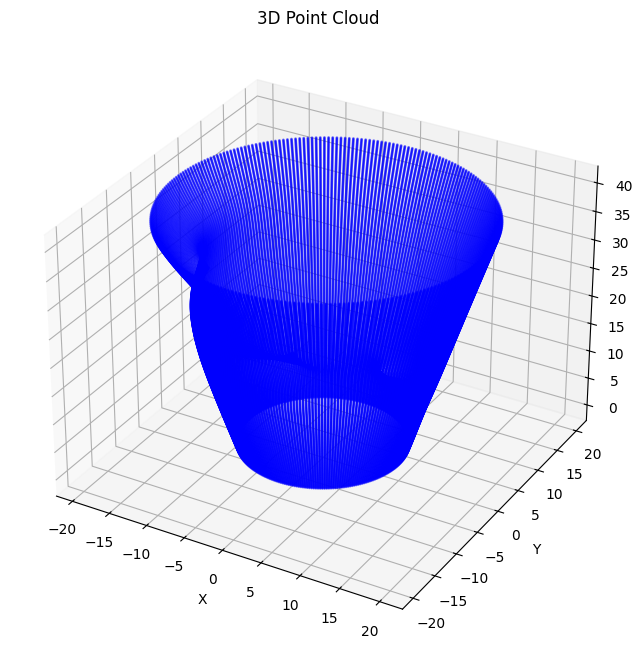

In [ ]:
# Step 1: Load and Visualize the 3D Data
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Load the 3D point cloud data
file_path = '3d_shape_points_data.npz'
data = np.load(file_path)

# Extract the 3D points
points = data['points']

# Visualize the 3D point cloud
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points[:, 0], points[:, 1], points[:, 2], s=1, c='blue', alpha=0.5)
ax.set_title('3D Point Cloud')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()

Original number of points: 65536
Points after outlier removal: 65536
Center of mass before normalization: [ 0.16321747  0.12859206 19.999527  ]


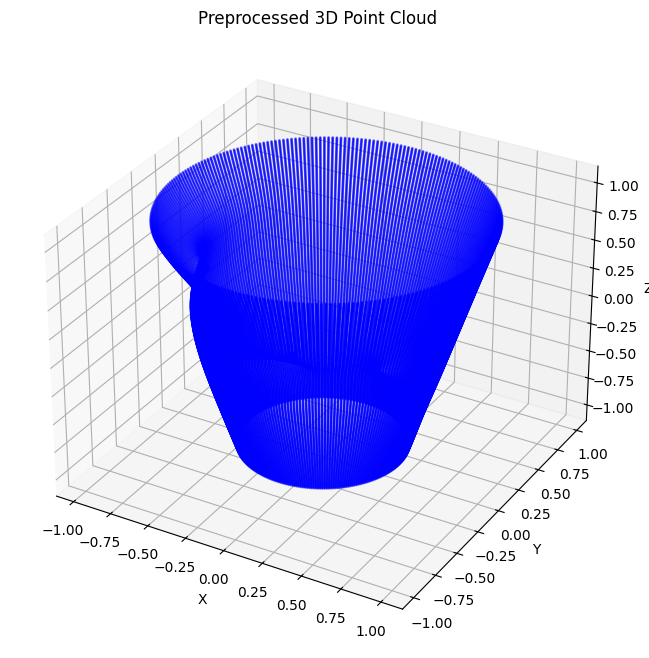

In [ ]:
# Step 2: Preprocess the Data
import numpy as np
from scipy import stats

# Function to remove statistical outliers
def remove_statistical_outliers(points, n_sigma=2):
    # Calculate z-scores for each dimension
    z_scores = np.abs(stats.zscore(points))
    # Find points where all dimensions are within n_sigma standard deviations
    mask = (z_scores < n_sigma).all(axis=1)
    return points[mask]

# Remove outliers
cleaned_points = remove_statistical_outliers(points)

# Normalize the point cloud to center at origin
center = np.mean(cleaned_points, axis=0)
normalized_points = cleaned_points - center

# Scale to unit cube
max_range = np.max(np.abs(normalized_points))
normalized_points = normalized_points / max_range

# Visualize the preprocessed point cloud
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(normalized_points[:, 0], normalized_points[:, 1], normalized_points[:, 2],
          s=1, c='blue', alpha=0.5)
ax.set_title('Preprocessed 3D Point Cloud')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Print statistics
print('Original number of points:', len(points))
print('Points after outlier removal:', len(cleaned_points))
print('Center of mass before normalization:', center)

plt.show()

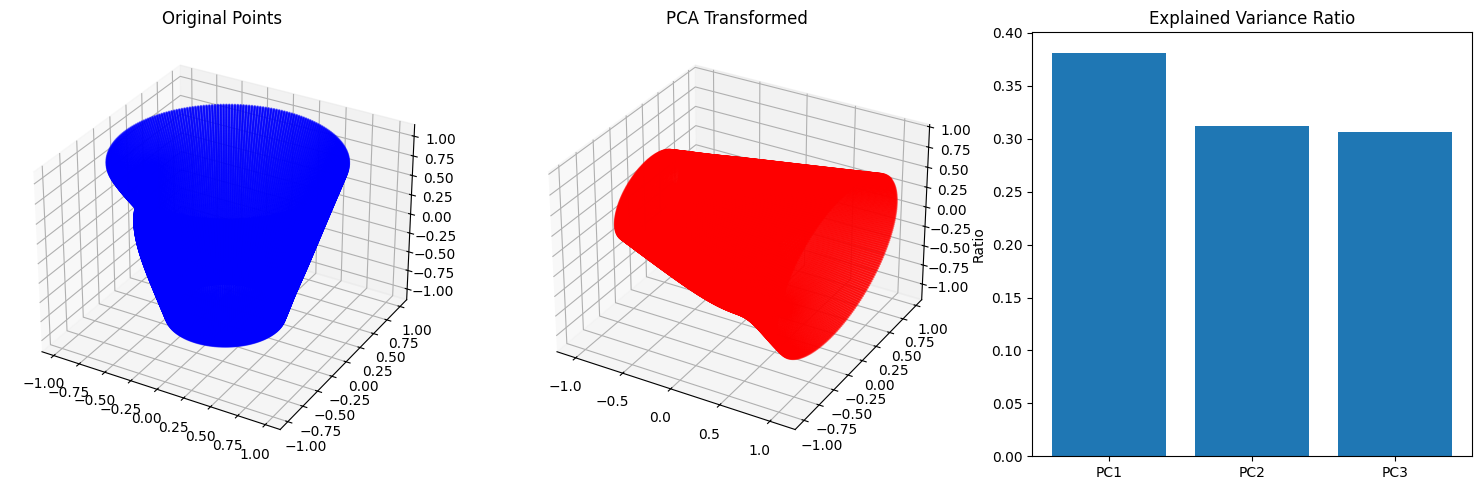

Principal Component Analysis Results:
Explained variance ratios: [0.38145635 0.31247053 0.30607307]
Principal axes (eigenvectors):
[[ 0.07629091  0.06303074  0.9950914 ]
 [ 0.7881457  -0.6151144  -0.02146259]
 [ 0.6107422   0.7859144  -0.09660504]]
Shape Metrics:
Approximate volume: 3.5842452690423703
Approximate surface area: 13.410877198457907


In [ ]:
# Step 3: Shape Analysis and PCA
import numpy as np
from sklearn.decomposition import PCA
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Perform PCA
pca = PCA(n_components=3)
pca_result = pca.fit_transform(normalized_points)

# Calculate explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_

# Visualize PCA components
fig = plt.figure(figsize=(15, 5))

# Original points
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(normalized_points[:, 0], normalized_points[:, 1], normalized_points[:, 2],
           c='blue', s=1, alpha=0.5)
ax1.set_title('Original Points')

# PCA transformed points
ax2 = fig.add_subplot(132, projection='3d')
ax2.scatter(pca_result[:, 0], pca_result[:, 1], pca_result[:, 2],
           c='red', s=1, alpha=0.5)
ax2.set_title('PCA Transformed')

# Principal directions
ax3 = fig.add_subplot(133)
ax3.bar(['PC1', 'PC2', 'PC3'], explained_variance_ratio)
ax3.set_title('Explained Variance Ratio')
ax3.set_ylabel('Ratio')

plt.tight_layout()
plt.show()

# Print shape analysis metrics
print('Principal Component Analysis Results:')
print('Explained variance ratios:', explained_variance_ratio)
print('Principal axes (eigenvectors):')
print(pca.components_)

# Calculate approximate volume using ConvexHull
hull = ConvexHull(normalized_points)
volume = hull.volume
surface_area = hull.area

print('\
Shape Metrics:')
print('Approximate volume:', volume)
print('Approximate surface area:', surface_area)

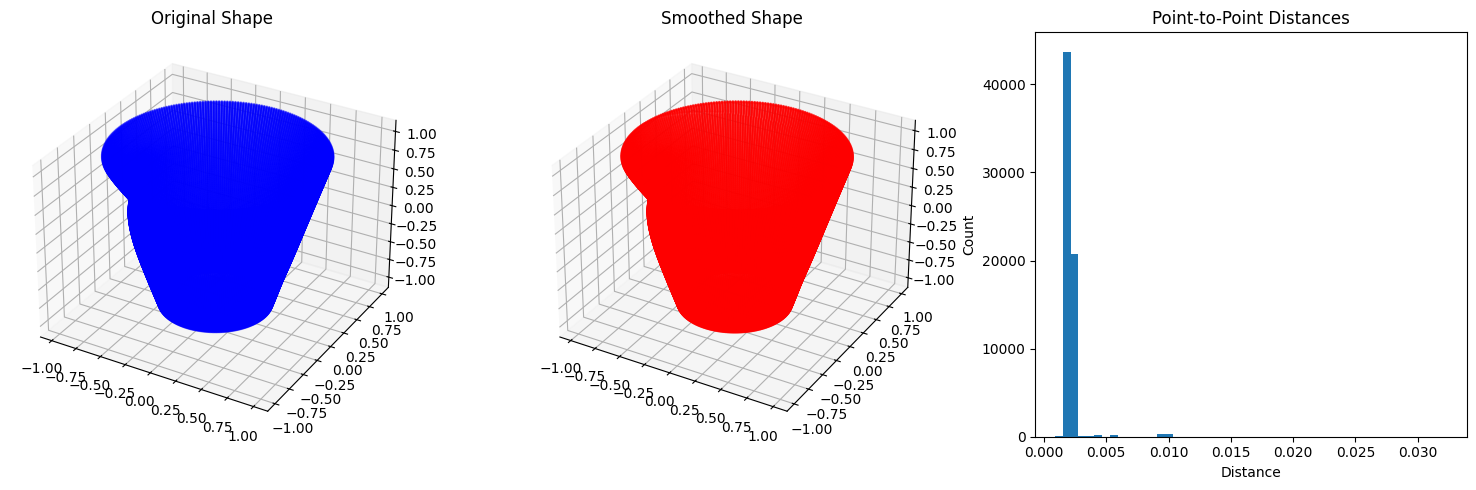

Reconstruction Evaluation Metrics:
Mean Squared Error: 4.9638957e-06
Hausdorff Distance: 0.032341883474823016
Shape Metrics Comparison:
Original Volume: 3.5842452690423703
Smoothed Volume: 3.5445339170122336
Original Surface Area: 13.410877198457907
Smoothed Surface Area: 13.302706406109335
Volume Change (%): -1.107941813388977
Surface Area Change (%): -0.806589984740225


In [ ]:
# Step 4 & 5: Shape Reconstruction and Evaluation
from sklearn.neighbors import NearestNeighbors
import numpy as np

def compute_hausdorff_distance(points1, points2):
    # Find nearest neighbors for both directions
    neigh1 = NearestNeighbors(n_neighbors=1)
    neigh2 = NearestNeighbors(n_neighbors=1)

    neigh1.fit(points1)
    neigh2.fit(points2)

    # Find distances from points1 to points2
    distances1, _ = neigh1.kneighbors(points2)
    distances2, _ = neigh2.kneighbors(points1)

    # Compute Hausdorff distance
    hausdorff_dist = max(np.max(distances1), np.max(distances2))
    return hausdorff_dist

# Perform simple surface smoothing using local averaging
def smooth_surface(points, k=10):
    nbrs = NearestNeighbors(n_neighbors=k).fit(points)
    distances, indices = nbrs.kneighbors(points)

    # Average positions with neighbors
    smoothed_points = np.array([np.mean(points[idx], axis=0) for idx in indices])
    return smoothed_points

# Smooth the surface
smoothed_points = smooth_surface(normalized_points)

# Compute metrics
mse = np.mean(np.sum((normalized_points - smoothed_points) ** 2, axis=1))
hausdorff = compute_hausdorff_distance(normalized_points, smoothed_points)

# Visualize original vs smoothed
fig = plt.figure(figsize=(15, 5))

# Original shape
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(normalized_points[:, 0], normalized_points[:, 1], normalized_points[:, 2],
           c='blue', s=1, alpha=0.5)
ax1.set_title('Original Shape')

# Smoothed shape
ax2 = fig.add_subplot(132, projection='3d')
ax2.scatter(smoothed_points[:, 0], smoothed_points[:, 1], smoothed_points[:, 2],
           c='red', s=1, alpha=0.5)
ax2.set_title('Smoothed Shape')

# Distance histogram
distances = np.sqrt(np.sum((normalized_points - smoothed_points) ** 2, axis=1))
ax3 = fig.add_subplot(133)
ax3.hist(distances, bins=50)
ax3.set_title('Point-to-Point Distances')
ax3.set_xlabel('Distance')
ax3.set_ylabel('Count')

plt.tight_layout()
plt.show()

# Print evaluation metrics
print('Reconstruction Evaluation Metrics:')
print('Mean Squared Error:', mse)
print('Hausdorff Distance:', hausdorff)

# Calculate volume and surface area of smoothed shape
smoothed_hull = ConvexHull(smoothed_points)
smoothed_volume = smoothed_hull.volume
smoothed_surface_area = smoothed_hull.area

print('\
Shape Metrics Comparison:')
print('Original Volume:', volume)
print('Smoothed Volume:', smoothed_volume)
print('Original Surface Area:', surface_area)
print('Smoothed Surface Area:', smoothed_surface_area)
print('Volume Change (%):', (smoothed_volume - volume) / volume * 100)
print('Surface Area Change (%):', (smoothed_surface_area - surface_area) / surface_area * 100)

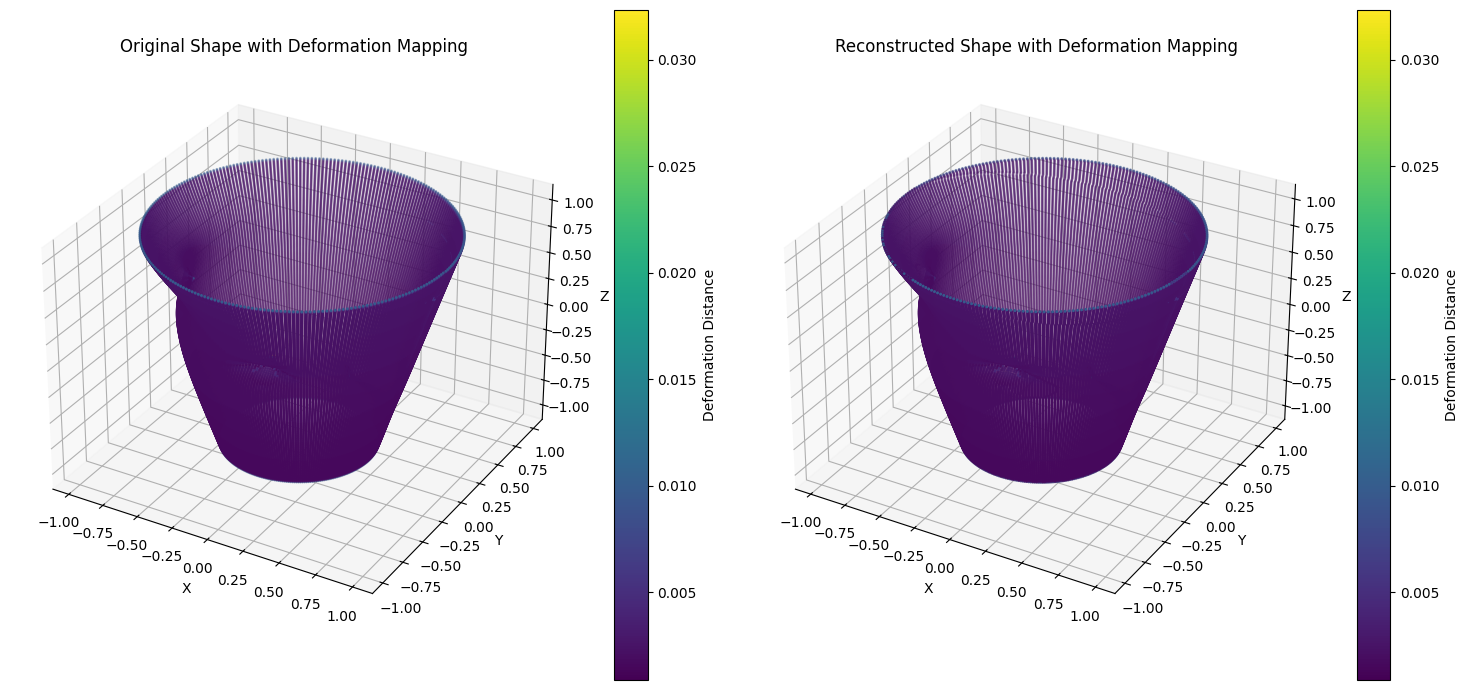

Reconstructed shape saved as: reconstructed_shape.npz


In [ ]:
# Step 6: Visualize Results with Deformation Mapping
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Compute deformation distances
point_distances = np.sqrt(np.sum((normalized_points - smoothed_points) ** 2, axis=1))

# Visualize side-by-side comparison
fig = plt.figure(figsize=(15, 7))

# Original shape
ax1 = fig.add_subplot(121, projection='3d')
sc1 = ax1.scatter(normalized_points[:, 0], normalized_points[:, 1], normalized_points[:, 2],
                  c=point_distances, cmap='viridis', s=1)
ax1.set_title('Original Shape with Deformation Mapping')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
plt.colorbar(sc1, ax=ax1, label='Deformation Distance')

# Reconstructed shape
ax2 = fig.add_subplot(122, projection='3d')
sc2 = ax2.scatter(smoothed_points[:, 0], smoothed_points[:, 1], smoothed_points[:, 2],
                  c=point_distances, cmap='viridis', s=1)
ax2.set_title('Reconstructed Shape with Deformation Mapping')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
plt.colorbar(sc2, ax=ax2, label='Deformation Distance')

plt.tight_layout()
plt.show()

# Step 7: Export the Reconstructed Shape
# Save the reconstructed shape as .npz
output_file = 'reconstructed_shape.npz'
np.savez(output_file, points=smoothed_points)
print('Reconstructed shape saved as:', output_file)

Final


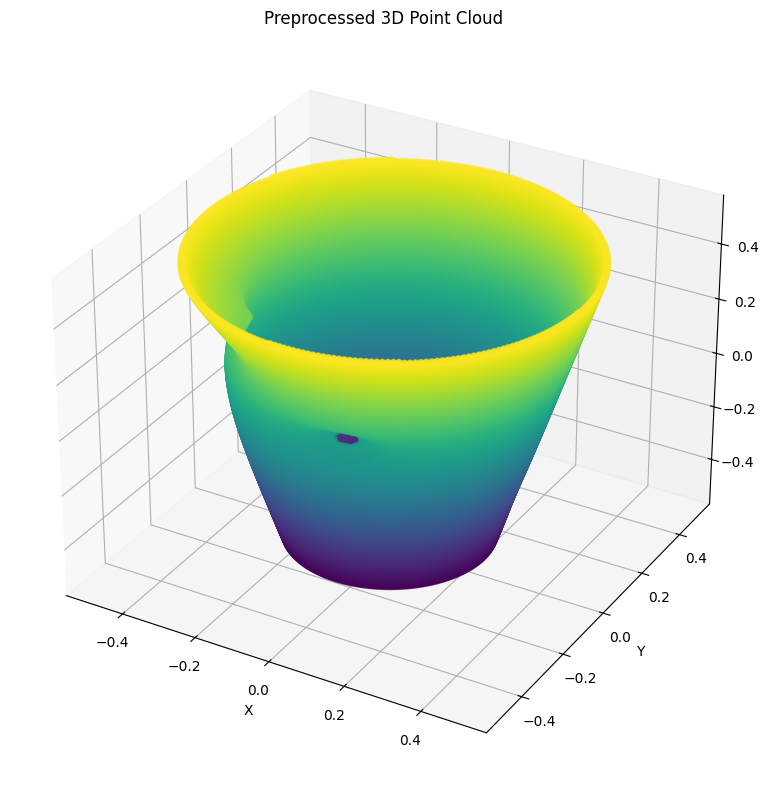

[Open3D WARNING] GLFW Error: Failed to detect any supported platform
[Open3D WARNING] GLFW initialized for headless rendering.
[Open3D WARNING] GLFW Error: OSMesa: Library not found
[Open3D WARNING] Failed to create window
[Open3D WARNING] [DrawGeometries] Failed creating OpenGL window.


In [ ]:
import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def load_and_preprocess_point_cloud(file_path):
    """
    Load 3D point cloud data, preprocess it, and visualize.

    Parameters:
    -----------
    file_path : str
        Path to the .npz file containing point cloud data

    Returns:
    --------
    processed_pcd : open3d.geometry.PointCloud
        Preprocessed point cloud
    """
    # Step 1: Load the data
    data = np.load(file_path)
    points = data['points']

    # Convert to Open3D point cloud
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points)

    # Step 2: Preprocess the data

    # 2.1 Remove statistical outliers
    # This removes points that are far from their neighbors
    processed_pcd, ind = pcd.remove_statistical_outlier(
        nb_neighbors=20,  # Number of neighbors to analyze for each point
        std_ratio=2.0     # Threshold for identifying outliers
    )

    # 2.2 Downsample using voxel grid
    # This reduces the number of points while preserving the overall shape
    processed_pcd = processed_pcd.voxel_down_sample(voxel_size=0.01)

    # 2.3 Normalize point cloud (center at origin and scale)
    points_array = np.asarray(processed_pcd.points)

    # Center the point cloud
    center = points_array.mean(axis=0)
    processed_pcd.translate(-center)

    # Optional: Scale to unit cube
    max_range = np.max(np.ptp(points_array, axis=0))
    processed_pcd.scale(1/max_range, center=(0,0,0))

    return processed_pcd

def visualize_point_cloud_matplotlib(pcd):
    """
    Visualize point cloud using Matplotlib

    Parameters:
    -----------
    pcd : open3d.geometry.PointCloud
        Point cloud to visualize
    """
    points = np.asarray(pcd.points)

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Scatter plot of points
    ax.scatter(points[:, 0], points[:, 1], points[:, 2],
               c=points[:, 2], cmap='viridis', alpha=0.6)

    ax.set_title('Preprocessed 3D Point Cloud')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

    plt.tight_layout()
    plt.show()

def visualize_point_cloud_open3d(pcd):
    """
    Visualize point cloud using Open3D

    Parameters:
    -----------
    pcd : open3d.geometry.PointCloud
        Point cloud to visualize
    """
    o3d.visualization.draw_geometries([pcd])

# Main execution
if __name__ == '__main__':
    # File path - replace with your actual file path
    file_path = '3d_shape_points_data.npz'

    # Load and preprocess point cloud
    processed_pcd = load_and_preprocess_point_cloud(file_path)

    # Visualize using Matplotlib
    visualize_point_cloud_matplotlib(processed_pcd)

    # Visualize using Open3D
    visualize_point_cloud_open3d(processed_pcd)